# -------------------- Adaboost from Strach ---------------------

### Importing Libraries

In [9]:
import pandas as pd
import numpy as np
from mlxtend.plotting import plot_decision_regions

### Dataset

In [10]:
df = pd.DataFrame()

In [11]:
df['X1'] = [1,2,3,4,5,6,6,7,9,9]
df['X2'] = [5,3,6,8,1,9,5,8,9,2]
df['label'] = [1,1,0,1,0,1,0,1,0,0]

In [12]:
df

,X1,X2,label
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,6,5,0
7,7,8,1
8,9,9,0
9,9,2,0


### Ploting Dataset

<AxesSubplot: xlabel='X1', ylabel='X2'>

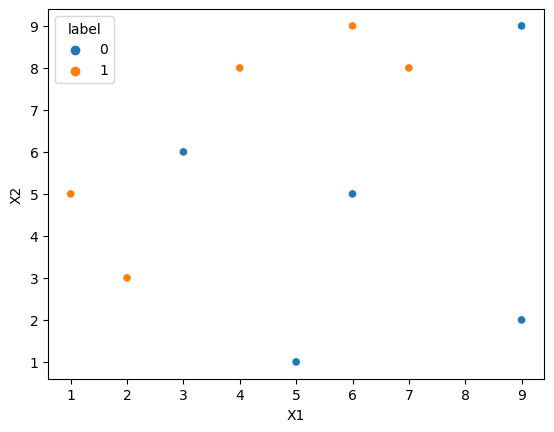

In [13]:
import seaborn as sns
sns.scatterplot(x=df['X1'],y=df['X2'],hue=df['label'])

### Assigning Weight to Each Record

In [14]:
df['weights'] = 1/df.shape[0]

In [15]:
df

,X1,X2,label,weights
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
5,6,9,1,0.1
6,6,5,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1


### Independent & Dependent Features

In [16]:
X = df.iloc[:,0:2].values     # Independent Feature   
y = df.iloc[:,2].values       # Dependent Feature

### Creating Model

In [17]:
from sklearn.tree import DecisionTreeClassifier

In [18]:
dt1 = DecisionTreeClassifier(max_depth=1)

In [19]:
# Step 2 - Train 1st model
dt1.fit(X,y)

DecisionTreeClassifier(max_depth=1)

### Tree Stumps

[Text(0.5, 0.75, 'x[0] <= 2.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.75, 0.25, 'gini = 0.469\nsamples = 8\nvalue = [5, 3]')]

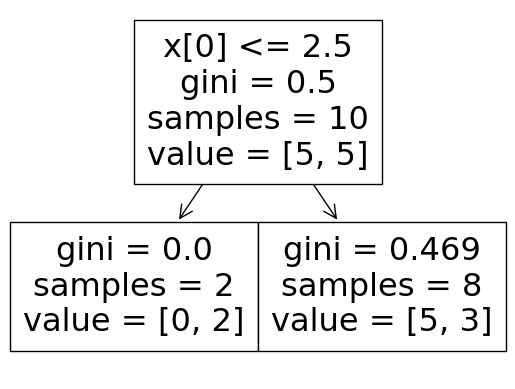

In [20]:
from sklearn.tree import plot_tree
plot_tree(dt1)

<AxesSubplot: >

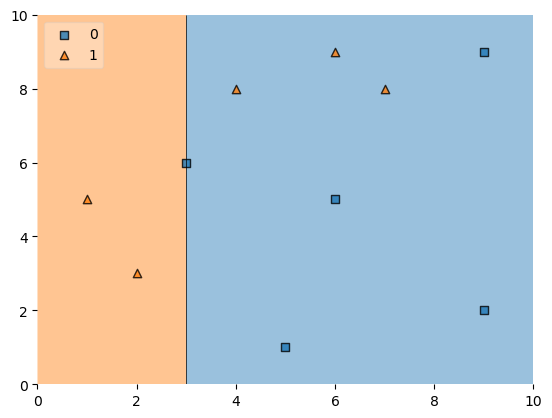

In [21]:
plot_decision_regions(X, y, clf=dt1, legend=2)

### Predicting Model 

In [22]:
y_pred = dt1.predict(X)

### Assiging Predicted data in to DataFrame

In [23]:
df['y_pred'] = y_pred

In [24]:
df

,X1,X2,label,weights,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,0
3,4,8,1,0.1,0
4,5,1,0,0.1,0
5,6,9,1,0.1,0
6,6,5,0,0.1,0
7,7,8,1,0.1,0
8,9,9,0,0.1,0
9,9,2,0,0.1,0


### Accuracy of model

In [25]:
from sklearn.metrics import accuracy_score
Accuracy  = accuracy_score(y_pred,y)
print("Accuracy of the Model :- ",Accuracy*100)

Accuracy of the Model :-  70.0


### Error in the Model

In [26]:
error = 1- Accuracy
print("Error in the Model:",round(error,2))

Error in the Model: 0.3


### Function For Calculating Weight of the Model

In [27]:
def calculate_model_weight(error):

  return 0.5*np.log((1-error)/(error))

### Calculate model weight

In [28]:
alpha1 = calculate_model_weight(0.3)
print("Weight of Model H1 :- ",alpha1)

Weight of Model H1 :-  0.42364893019360184


### Step 4 - Update weights

In [29]:
def update_row_weights(row,alpha=0.423):
  if row['label'] == row['y_pred']:
    return row['weights'] * np.exp(-alpha)
  else:
    return row['weights'] * np.exp(alpha)

In [30]:
df['updated_weights'] = df.apply(update_row_weights,axis=1)

In [31]:
df

,X1,X2,label,weights,y_pred,updated_weights
0,1,5,1,0.1,1,0.065508
1,2,3,1,0.1,1,0.065508
2,3,6,0,0.1,0,0.065508
3,4,8,1,0.1,0,0.152653
4,5,1,0,0.1,0,0.065508
5,6,9,1,0.1,0,0.152653
6,6,5,0,0.1,0,0.065508
7,7,8,1,0.1,0,0.152653
8,9,9,0,0.1,0,0.065508
9,9,2,0,0.1,0,0.065508


In [32]:
df['updated_weights'].sum()

0.9165153319682015

### Normalization of the Updated_Weights

In [33]:
df['nomalized_weights'] = df['updated_weights']/df['updated_weights'].sum()

In [34]:
df

,X1,X2,label,weights,y_pred,updated_weights,nomalized_weights
0,1,5,1,0.1,1,0.065508,0.071475
1,2,3,1,0.1,1,0.065508,0.071475
2,3,6,0,0.1,0,0.065508,0.071475
3,4,8,1,0.1,0,0.152653,0.166559
4,5,1,0,0.1,0,0.065508,0.071475
5,6,9,1,0.1,0,0.152653,0.166559
6,6,5,0,0.1,0,0.065508,0.071475
7,7,8,1,0.1,0,0.152653,0.166559
8,9,9,0,0.1,0,0.065508,0.071475
9,9,2,0,0.1,0,0.065508,0.071475


In [43]:
df['nomalized_weights'].sum()

1.0

### Creating Upper Range 

In [44]:
df['cumsum_upper'] = np.cumsum(df['nomalized_weights'])

### Creating Lower Range 

In [37]:
df['cumsum_lower'] = df['cumsum_upper'] - df['nomalized_weights']

In [38]:
df[['X1','X2','label','weights','y_pred','updated_weights','cumsum_lower','cumsum_upper']]

,X1,X2,label,weights,y_pred,updated_weights,cumsum_lower,cumsum_upper
0,1,5,1,0.1,1,0.065508,0.000000,0.071475
1,2,3,1,0.1,1,0.065508,0.071475,0.142950
2,3,6,0,0.1,0,0.065508,0.142950,0.214425
3,4,8,1,0.1,0,0.152653,0.214425,0.380983
4,5,1,0,0.1,0,0.065508,0.380983,0.452458
5,6,9,1,0.1,0,0.152653,0.452458,0.619017
6,6,5,0,0.1,0,0.065508,0.619017,0.690492
7,7,8,1,0.1,0,0.152653,0.690492,0.857050
8,9,9,0,0.1,0,0.065508,0.857050,0.928525
9,9,2,0,0.1,0,0.065508,0.928525,1.000000


#### Function for creating Random & selecting on the base of Upper & Lower Range

In [45]:
def create_new_dataset(df):

  indices = []

  for i in range(df.shape[0]):
    a = np.random.random()
    for index,row in df.iterrows():
      if row['cumsum_upper'] > a and a > row['cumsum_lower']:
        indices.append(index)
  return indices

In [46]:
index_values = create_new_dataset(df)

index_values

[3, 8, 4, 1, 5, 7, 2, 7, 7, 5]

In [47]:
second_df = df.iloc[index_values,[0,1,2,3]]

```python
index_values :- No of Rows from old Dataset
[0,1,2,3] :-  No. of Columns from old Dataset
```

In [48]:
second_df

,X1,X2,label,weights
3,4,8,1,0.1
8,9,9,0,0.1
4,5,1,0,0.1
1,2,3,1,0.1
5,6,9,1,0.1
7,7,8,1,0.1
2,3,6,0,0.1
7,7,8,1,0.1
7,7,8,1,0.1
5,6,9,1,0.1


### Creating 2nd Tree

In [77]:
dt2 = DecisionTreeClassifier(max_depth=1)

In [78]:
X = second_df.iloc[:,0:2].values           # Independent features
y = second_df.iloc[:,2].values             # Dependent Features

In [79]:
dt2.fit(X,y)

DecisionTreeClassifier(max_depth=1)

#### Plotting Decision Tree

[Text(0.5, 0.75, 'x[1] <= 7.0\ngini = 0.42\nsamples = 10\nvalue = [3, 7]'),
 Text(0.25, 0.25, 'gini = 0.444\nsamples = 3\nvalue = [2, 1]'),
 Text(0.75, 0.25, 'gini = 0.245\nsamples = 7\nvalue = [1, 6]')]

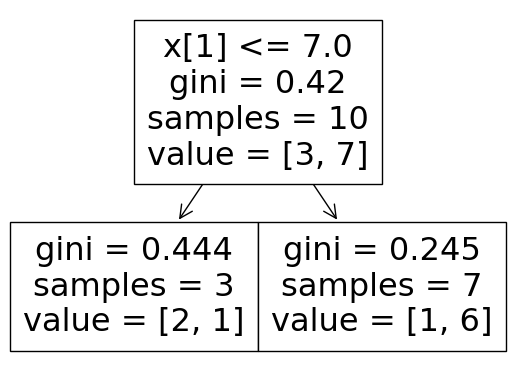

In [80]:
plot_tree(dt2)

#### Plotting Decision Boundry after creating 2nd Dataset

<AxesSubplot: >

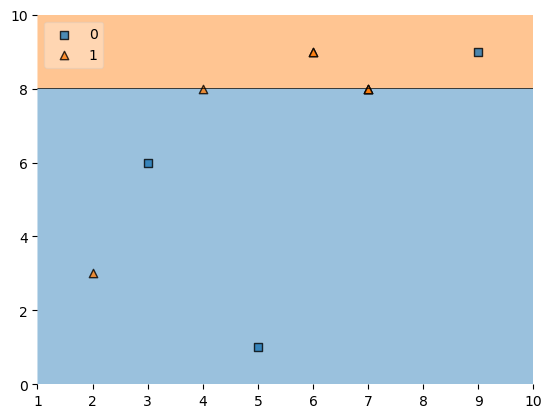

In [81]:
plot_decision_regions(X, y, clf=dt2, legend=2)

In [82]:
y_pred = dt2.predict(X)
print(y_pred)

[1 1 0 0 1 1 0 1 1 1]


#### Accuracy of Model

In [84]:
Accuracy = accuracy_score(y_pred,y)
print("Accuracy of the Model",Accuracy*100)

Accuracy of the Model 80.0


In [85]:
second_df['y_pred'] = dt2.predict(X)

In [86]:
second_df

,X1,X2,label,weights,y_pred,updated_weights
3,4,8,1,0.1,1,0.033622
8,9,9,0,0.1,1,0.297427
4,5,1,0,0.1,0,0.033622
1,2,3,1,0.1,0,0.297427
5,6,9,1,0.1,1,0.033622
7,7,8,1,0.1,1,0.033622
2,3,6,0,0.1,0,0.033622
7,7,8,1,0.1,1,0.033622
7,7,8,1,0.1,1,0.033622
5,6,9,1,0.1,1,0.033622


#### Calculate Weight of Weight 

In [87]:
alpha2 = calculate_model_weight(0.1)

In [88]:
alpha2

1.0986122886681098

#### Update weights of records

In [89]:
def update_row_weights(row,alpha=1.09):
  if row['label'] == row['y_pred']:
    return row['weights'] * np.exp(-alpha)
  else:
    return row['weights'] * np.exp(alpha)

In [90]:
second_df['updated_weights'] = second_df.apply(update_row_weights,axis=1)

#### Updated Weight of Dataframe

In [92]:
second_df

,X1,X2,label,weights,y_pred,updated_weights
3,4,8,1,0.1,1,0.033622
8,9,9,0,0.1,1,0.297427
4,5,1,0,0.1,0,0.033622
1,2,3,1,0.1,0,0.297427
5,6,9,1,0.1,1,0.033622
7,7,8,1,0.1,1,0.033622
2,3,6,0,0.1,0,0.033622
7,7,8,1,0.1,1,0.033622
7,7,8,1,0.1,1,0.033622
5,6,9,1,0.1,1,0.033622


#### Normalized the Weight 

In [93]:
second_df['nomalized_weights'] = second_df['updated_weights']/second_df['updated_weights'].sum()

In [94]:
second_df

,X1,X2,label,weights,y_pred,updated_weights,nomalized_weights
3,4,8,1,0.1,1,0.033622,0.038922
8,9,9,0,0.1,1,0.297427,0.344313
4,5,1,0,0.1,0,0.033622,0.038922
1,2,3,1,0.1,0,0.297427,0.344313
5,6,9,1,0.1,1,0.033622,0.038922
7,7,8,1,0.1,1,0.033622,0.038922
2,3,6,0,0.1,0,0.033622,0.038922
7,7,8,1,0.1,1,0.033622,0.038922
7,7,8,1,0.1,1,0.033622,0.038922
5,6,9,1,0.1,1,0.033622,0.038922


In [95]:
second_df['nomalized_weights'].sum()

0.9999999999999999

In [96]:
second_df['cumsum_upper'] = np.cumsum(second_df['nomalized_weights'])

In [97]:
second_df['cumsum_lower'] = second_df['cumsum_upper'] - second_df['nomalized_weights']

In [98]:
second_df[['X1','X2','label','weights','y_pred','nomalized_weights','cumsum_lower','cumsum_upper']]

,X1,X2,label,weights,y_pred,nomalized_weights,cumsum_lower,cumsum_upper
3,4,8,1,0.1,1,0.038922,0.000000,0.038922
8,9,9,0,0.1,1,0.344313,0.038922,0.383235
4,5,1,0,0.1,0,0.038922,0.383235,0.422157
1,2,3,1,0.1,0,0.344313,0.422157,0.766470
5,6,9,1,0.1,1,0.038922,0.766470,0.805392
7,7,8,1,0.1,1,0.038922,0.805392,0.844313
2,3,6,0,0.1,0,0.038922,0.844313,0.883235
7,7,8,1,0.1,1,0.038922,0.883235,0.922157
7,7,8,1,0.1,1,0.038922,0.922157,0.961078
5,6,9,1,0.1,1,0.038922,0.961078,1.000000


In [99]:
index_values = create_new_dataset(second_df)

In [100]:
third_df = second_df.iloc[index_values,[0,1,2,3]]

In [101]:
third_df

,X1,X2,label,weights
7,7,8,1,0.1
8,9,9,0,0.1
7,7,8,1,0.1
7,7,8,1,0.1
8,9,9,0,0.1
7,7,8,1,0.1
7,7,8,1,0.1
8,9,9,0,0.1
5,6,9,1,0.1
8,9,9,0,0.1


#### Creating 3rd Model

In [104]:
dt3 = DecisionTreeClassifier(max_depth=1)

X = third_df.iloc[:,0:2].values                  # Independent Feature 
y = third_df.iloc[:,2].values                    # Dependent Feature 

dt3.fit(X,y)

DecisionTreeClassifier(max_depth=1)

<AxesSubplot: >

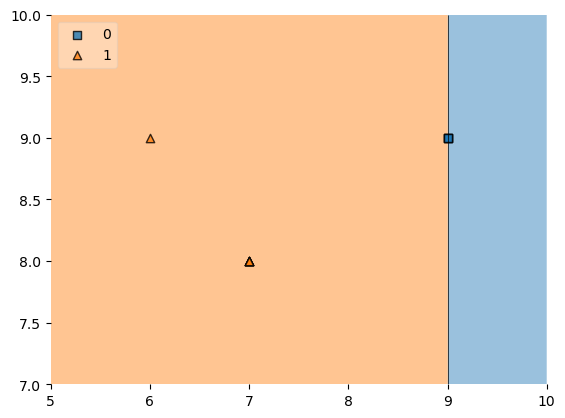

In [105]:
plot_decision_regions(X, y, clf=dt3, legend=2)

In [109]:
y_pred = dt3.predict(X)
y_pred

array([1, 0, 1, 1, 0, 1, 1, 0, 1, 0])

#### Accuracy of the Model

In [114]:
Accuracy = accuracy_score(y_pred,y)
print("Accuracy of the Model",Accuracy*100)

Accuracy of the Model 100.0


### Error of Model

In [117]:
error = 1-Accuracy
print(error*100)

0.0


In [106]:
third_df['y_pred'] = dt3.predict(X)

In [372]:
third_df

,X1,X2,label,weights,y_pred
3,4,8,1,0.1,0
0,1,5,1,0.1,1
6,6,5,0,0.1,1
0,1,5,1,0.1,0
0,1,5,1,0.1,1
3,4,8,1,0.1,0
0,1,5,1,0.1,0
0,1,5,1,0.1,0
0,1,5,1,0.1,0
0,1,5,1,0.1,1


### Updated Calculate_model_Weight Function

In [119]:
def calculate_model_weight(error):

  return 0.5*np.log((1-error)/(error+0.000001))

In [120]:
alpha3 = calculate_model_weight(0.0)
alpha3

6.907755278982137

In [374]:
print(alpha1,alpha2,alpha3)

0.42364893019360184 1.0986122886681098 -0.4236489301936017


## Prediction

#### Test Case 1

In [121]:
query = np.array([1,5]).reshape(1,2)
dt1.predict(query)

array([1])

In [122]:
dt2.predict(query)

array([0])

In [123]:
dt3.predict(query)

array([1])

In [126]:
alpha1*1 + alpha2*(-1) + alpha3*(1)
### output 0 means multiply by -1 
### output 1 means multiply by  1

6.232791920507629

In [125]:
np.sign(6.23)

1.0

### Test Case 2

In [127]:
query = np.array([9,9]).reshape(1,2)
dt1.predict(query)

array([0])

In [128]:
dt2.predict(query)

array([1])

In [129]:
dt3.predict(query)

array([0])

In [130]:
alpha1*(-1) + alpha2*(1) + alpha3*(-1)

-6.232791920507629

In [131]:
np.sign(-6.23)

-1.0